In [1]:
# Standard libs
import os
import random

# Data processing
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
%matplotlib inline

# Image processing
import cv2

# PyTorch
import torch
from torch.utils.data import DataLoader
import torchviz
import torch.optim as optim
import torch.nn as nn

# Models
from models.clip_based_unet import CLIPResnetSegmentationModel

# Utils and config
from utils import visualize, analyze, training_plot, save_statistics
from Datasets.Segmentation.data_providers import test_dataset, val_dataset, train_dataset
from config import SEED, BATCH_SIZE

# Device setup
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


from tqdm import tqdm

# 0. Image samples Visualization

Hover over images to see the the pixel values

In [2]:
print("Cats")
image = cv2.imread("Datasets/Segmentation/TrainVal/color/Abyssinian_10.jpg")
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
mask = cv2.imread("Datasets/Segmentation/TrainVal/label/Abyssinian_10.png")
mask = cv2.cvtColor(mask, cv2.COLOR_BGR2RGB)

analyze(image, mask,ismask=False)

print("Dogs")
image = cv2.imread("Datasets/Segmentation/TrainVal/color/american_bulldog_146.jpg")
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
mask = cv2.imread("Datasets/Segmentation/TrainVal/label/american_bulldog_146.png")
mask = cv2.cvtColor(mask, cv2.COLOR_BGR2RGB)

analyze(image, mask,ismask=False)

Cats


Dogs


# Image Input

# 1.  Dataset preprocessing and augmentation

In [26]:
# Preprocessing made here:
from Datasets.Segmentation.data_providers import test_dataset, val_dataset, train_dataset

# to create DataLoaders
BATCH_SIZE = 64
train_dataloader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_dataloader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_dataloader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=True)

# Example: Fetch a batch
images, masks, _ = next(iter(train_dataloader))
print(f"Image batch shape: {images.shape}, Mask batch shape: {masks.shape}")


Image batch shape: torch.Size([64, 3, 224, 224]), Mask batch shape: torch.Size([64, 224, 224])


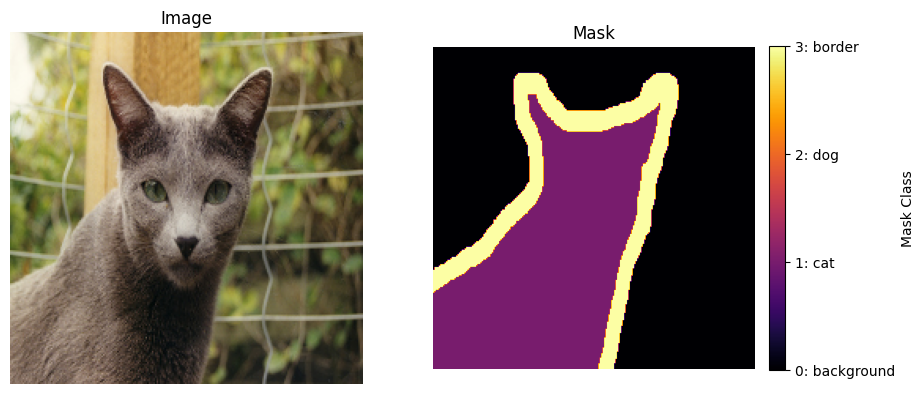

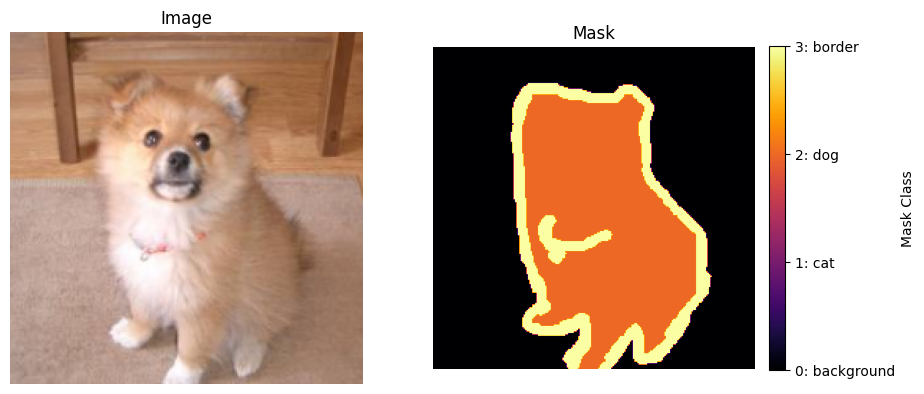

Image shape:  torch.Size([3, 224, 224])
Mask shape:  torch.Size([224, 224])


In [27]:
N=random.randint(0,BATCH_SIZE-1)
visualize(images[N].permute(1, 2, 0).numpy(),masks[N].numpy())
N=random.randint(0,BATCH_SIZE-1)
visualize(images[N].permute(1, 2, 0).numpy(),masks[N].numpy())
print("Image shape: ",images[N].shape)
print("Mask shape: ",masks[N].shape)

# 2. Segmentation network design and implementation

### 2.a) UNet-based end-to-end segmentation neural network

In [31]:
from models.unet_model import UNet # Implemented Here

model = UNet(input_channels=3, n_filters=64,  n_classes=4)


# Test output shape
BATCH_SIZE = 1
train_dataloader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
images, masks, _ = next(iter(train_dataloader))

output = model(images)
print("Output shape: ",output.shape)
print(output.shape)

Output shape:  torch.Size([1, 4, 224, 224])
torch.Size([1, 4, 224, 224])


##### The model architecture

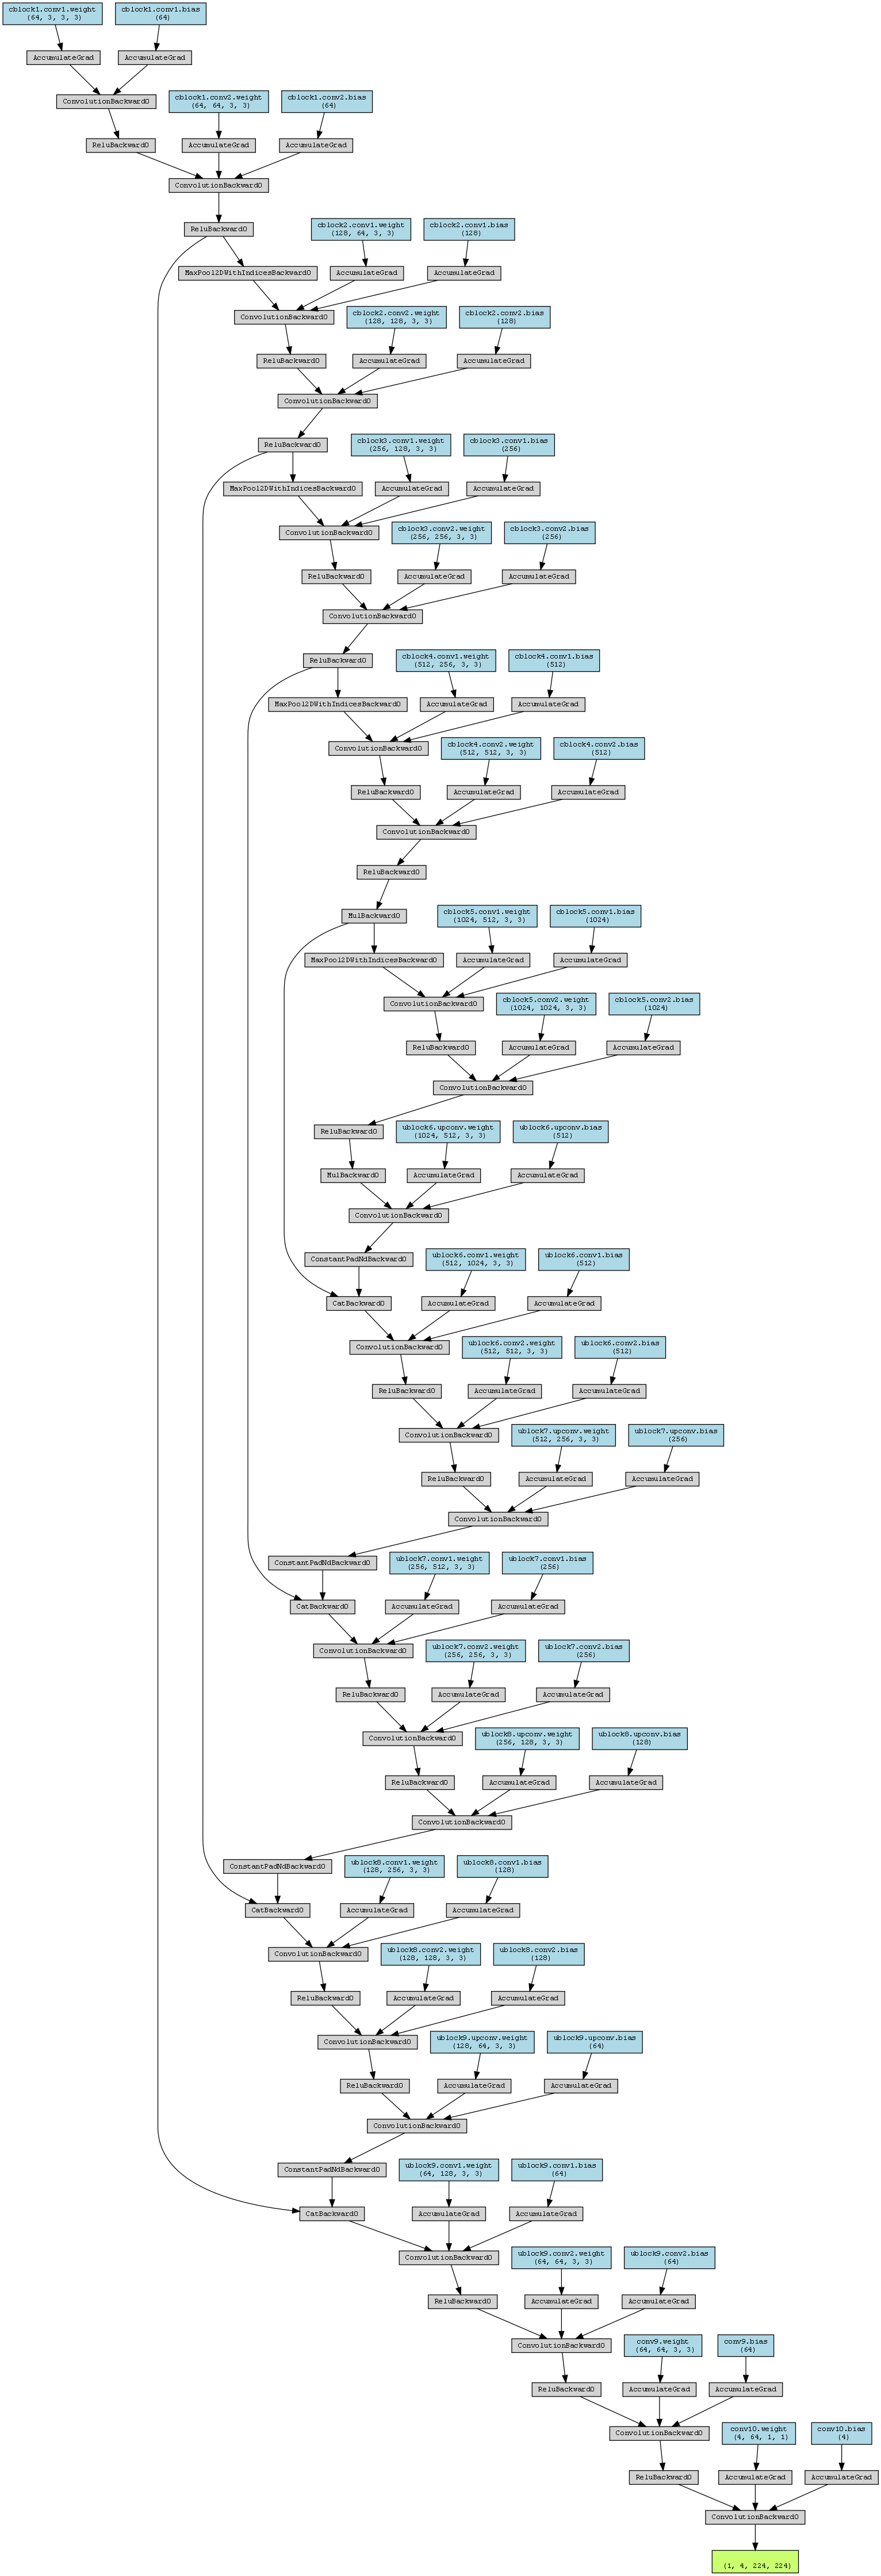

In [32]:
dot = torchviz.make_dot(output, params=dict(model.named_parameters()))
dot.format = 'png'
dot.render("nn_graph")
from IPython.display import Image
Image("nn_graph.png")

##### Model Training

Best epoch:
     train_iou  train_loss   val_iou  val_loss
36   0.509226    0.861479  0.516632  0.880136


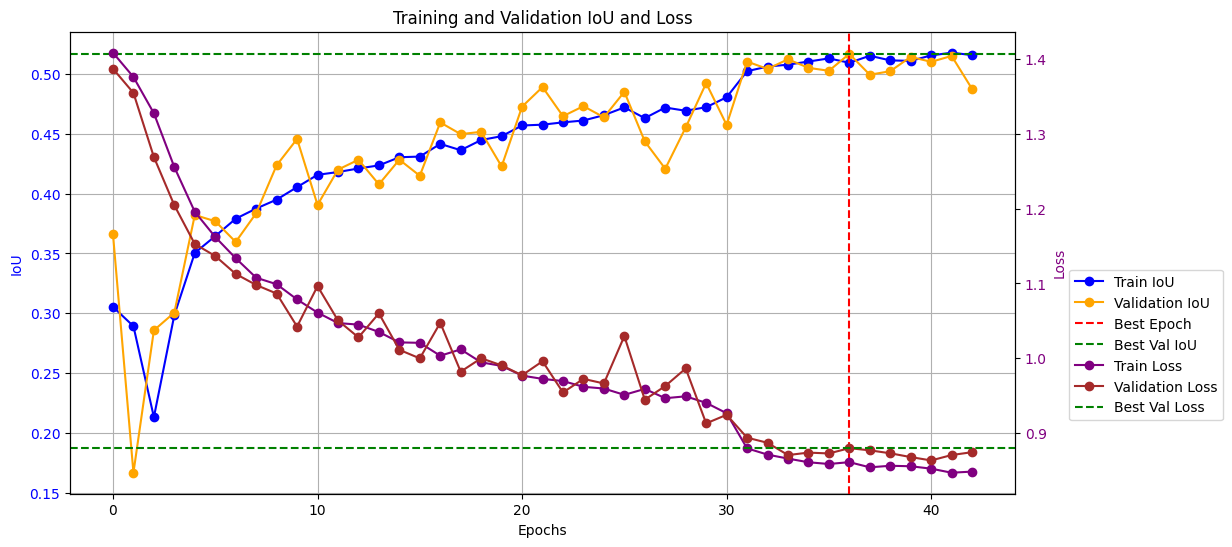

In [33]:
training_plot("UNet_RAW_experiment/result_outputs/summary.csv")

### 2.b) Autoencoder pre-training for segmentation

##### Autoencoder Definition

In [34]:
from models.autoencoder import Autoencoder # Implemented Here

autoencoder = Autoencoder(input_channels=3, n_filters=64).to(device)
print("autoencoder keys: ", autoencoder.state_dict().keys())

# Load pretrained weights from our an early model that we forgot to track
pretrained_weights = torch.load("models/weights/autoencoder/autoencoder_weights_init.pth", map_location=device)
# Filter and rename keys to match the autoencoder's state_dict
filtered_weights = {k.replace("inc.double_conv", "cblock1.conv").replace("down1.maxpool_conv.1.double_conv", "cblock2.conv")
					.replace("down2.maxpool_conv.1.double_conv", "cblock3.conv").replace("down3.maxpool_conv.1.double_conv", "cblock4.conv")
					.replace("down4.maxpool_conv.1.double_conv", "cblock5.conv"): v
					for k, v in pretrained_weights.items() if k in autoencoder.state_dict()}

# Load the filtered weights
autoencoder.load_state_dict(filtered_weights, strict=False)

autoencoder keys:  odict_keys(['cblock1.conv1.weight', 'cblock1.conv1.bias', 'cblock1.conv2.weight', 'cblock1.conv2.bias', 'cblock2.conv1.weight', 'cblock2.conv1.bias', 'cblock2.conv2.weight', 'cblock2.conv2.bias', 'cblock3.conv1.weight', 'cblock3.conv1.bias', 'cblock3.conv2.weight', 'cblock3.conv2.bias', 'cblock4.conv1.weight', 'cblock4.conv1.bias', 'cblock4.conv2.weight', 'cblock4.conv2.bias', 'cblock5.conv1.weight', 'cblock5.conv1.bias', 'cblock5.conv2.weight', 'cblock5.conv2.bias', 'ublock6.upconv.weight', 'ublock6.upconv.bias', 'ublock6.conv1.weight', 'ublock6.conv1.bias', 'ublock6.conv2.weight', 'ublock6.conv2.bias', 'ublock7.upconv.weight', 'ublock7.upconv.bias', 'ublock7.conv1.weight', 'ublock7.conv1.bias', 'ublock7.conv2.weight', 'ublock7.conv2.bias', 'ublock8.upconv.weight', 'ublock8.upconv.bias', 'ublock8.conv1.weight', 'ublock8.conv1.bias', 'ublock8.conv2.weight', 'ublock8.conv2.bias', 'ublock9.upconv.weight', 'ublock9.upconv.bias', 'ublock9.conv1.weight', 'ublock9.conv1.bi

C:\Users\jorge\AppData\Local\Temp\ipykernel_23972\638465348.py:7: FutureWarning:

You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.



_IncompatibleKeys(missing_keys=['cblock1.conv1.weight', 'cblock1.conv1.bias', 'cblock1.conv2.weight', 'cblock1.conv2.bias', 'cblock2.conv1.weight', 'cblock2.conv1.bias', 'cblock2.conv2.weight', 'cblock2.conv2.bias', 'cblock3.conv1.weight', 'cblock3.conv1.bias', 'cblock3.conv2.weight', 'cblock3.conv2.bias', 'cblock4.conv1.weight', 'cblock4.conv1.bias', 'cblock4.conv2.weight', 'cblock4.conv2.bias', 'cblock5.conv1.weight', 'cblock5.conv1.bias', 'cblock5.conv2.weight', 'cblock5.conv2.bias', 'ublock6.upconv.weight', 'ublock6.upconv.bias', 'ublock6.conv1.weight', 'ublock6.conv1.bias', 'ublock6.conv2.weight', 'ublock6.conv2.bias', 'ublock7.upconv.weight', 'ublock7.upconv.bias', 'ublock7.conv1.weight', 'ublock7.conv1.bias', 'ublock7.conv2.weight', 'ublock7.conv2.bias', 'ublock8.upconv.weight', 'ublock8.upconv.bias', 'ublock8.conv1.weight', 'ublock8.conv1.bias', 'ublock8.conv2.weight', 'ublock8.conv2.bias', 'ublock9.upconv.weight', 'ublock9.upconv.bias', 'ublock9.conv1.weight', 'ublock9.conv1.b

##### Autoencoder Training

In [35]:


retrain = False

# Log of Training
log_dir = "models/weights/autoencoder"
log_csv_name = "autoencoder_training_log.csv"

train_dataloader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)

epochs = 40
learning_rate = 1e-3

optimizer = optim.Adam(autoencoder.parameters(), lr=learning_rate)
criterion = nn.MSELoss()

# Implement the LR Scheduler
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5, verbose=True)

if retrain:
    min_loss = float("inf")  # Initialize to a large value
    # Training loop
    for epoch in range(epochs):
        autoencoder.train()
        total_loss = 0

        with tqdm(total=len(train_dataloader), desc=f"Epoch {epoch+1}/{epochs}", unit="batch") as pbar:
            for images, _ , _ in train_dataloader:  # Ignore masks
                images = images.to(device)

                # Forward pass
                outputs = autoencoder(images)
                loss = criterion(outputs, images)

                # Backward pass
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

                total_loss += loss.item()

                # Update the progress bar with the loss
                pbar.set_postfix(loss=loss.item())
                pbar.update(1)

        avg_loss = total_loss / len(train_dataloader)

        # Logging statistics
        stats_dict = {
            "epoch": epoch,
            "avg_loss": avg_loss,
            "learning_rate": learning_rate
        }
        save_statistics(log_dir, log_csv_name, stats_dict)

        print(f"Epoch [{epoch}/{epochs}], Loss: {avg_loss:.6f}, Learning Rate: {learning_rate:.6f}")

        # Step the scheduler based on the average loss
        scheduler.step(avg_loss)
        learning_rate = scheduler.optimizer.param_groups[0]['lr']

        if avg_loss < min_loss:
            min_loss = avg_loss
            model_filename = f"autoencoder_weights_{round(min_loss, 6)}.pth"  # Round to make filenames clean
            save_dir = os.path.join(log_dir, model_filename)
            torch.save(autoencoder.state_dict(), save_dir)
            print(f"Model saved to {save_dir}")

c:\Users\jorge\anaconda3\envs\cv_segmentation\lib\site-packages\torch\optim\lr_scheduler.py:60: UserWarning:

The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.



##### Testing Autoencoder's Output

C:\Users\jorge\AppData\Local\Temp\ipykernel_23972\3483079880.py:5: FutureWarning:

You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.

Clipping input data to the valid range for imshow with RGB d

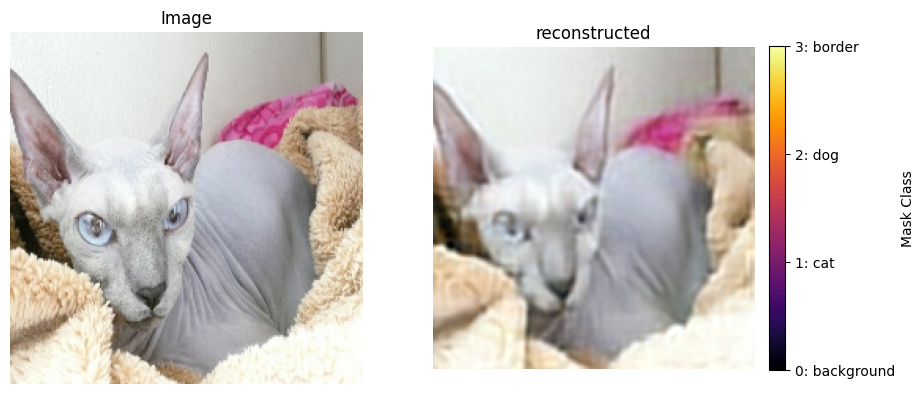

Image shape:  torch.Size([3, 224, 224])
Reconstructed shape:  torch.Size([3, 224, 224])


In [38]:
images, masks, _ = next(iter(val_dataloader))
N=random.randint(0,BATCH_SIZE-1)

autoencoder = Autoencoder(input_channels=3, n_filters=64).to(device)
weights = torch.load("models/weights/autoencoder/autoencoder_weights_0.002858656363969203.pth", map_location=device)
autoencoder.load_state_dict(weights, strict=False)
autoencoder.to(device)

autoencoder.eval()
with torch.no_grad():
    reconstructed = autoencoder(images[N])


visualize(images[N].permute(1, 2, 0).numpy(),reconstructed.permute(1, 2, 0).numpy(),"reconstructed")
print("Image shape: ",images[N].shape)
print("Reconstructed shape: ",reconstructed.shape)

##### Model Training

(Leveraging Autoencoder's weights to train segmentation on UNet)

Best epoch:
     train_iou  train_loss   val_iou  val_loss
29   0.346953    1.178435  0.365283     1.181


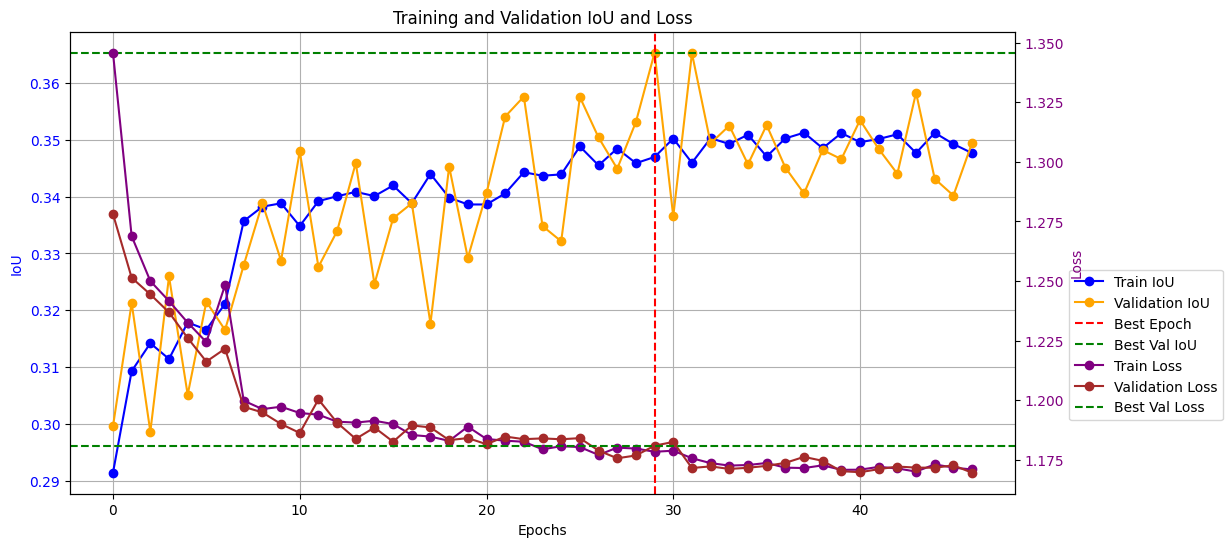

In [41]:
training_plot("UNet_AUTOENCODER_experiment/result_outputs/summary.csv")

### 2.c) CLIP Features fir segmentation

In [ ]:
# Model implementedin
from models.clip_based_unet import CLIPResnetSegmentationModel

##### Model Training

Best epoch:
     train_iou  train_loss   val_iou  val_loss
21   0.644959    0.590987  0.686761  0.575716


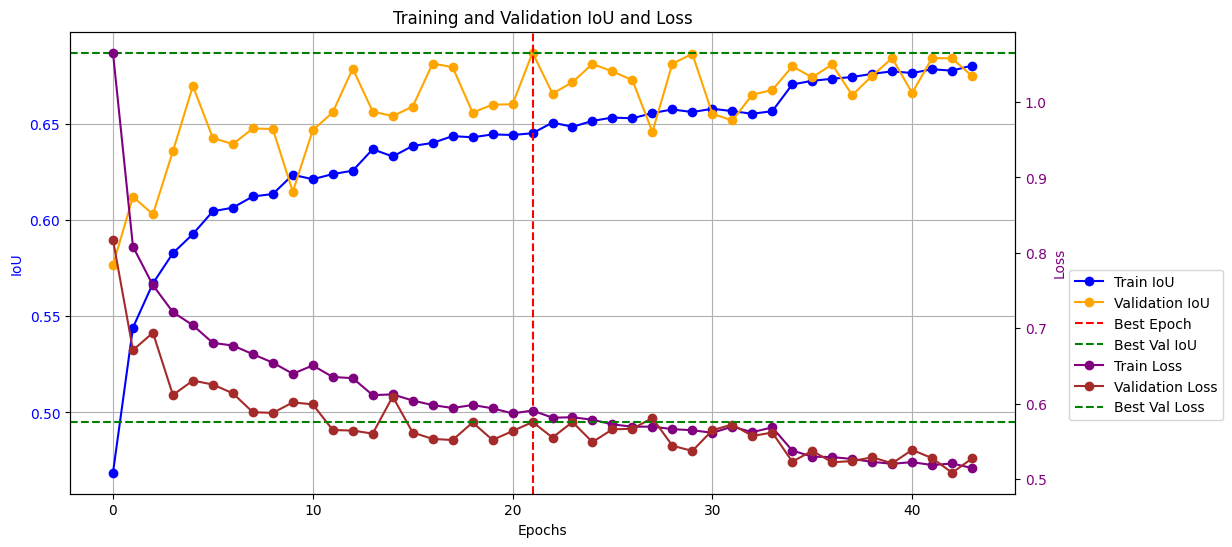

In [42]:
training_plot("UNet_CLIP_experiment/result_outputs/summary.csv")

### 2.d) Prompt-based segmentation

##### New Dataset Generation


Script to generate new dataset located in:

```python
from Datasets.Prompt_based_segmentation.heatmap_generation import generate_heatmaps
```

which takes the data from the segmentation dataset and greates the heatmap and corresponding masks

In [89]:


# Data providers for promopt-based segmentation
from Datasets.Prompt_based_segmentation.data_providers import test_dataset,val_dataset,train_dataset


# Create DataLoaders
BATCH_SIZE = 24
train_dataloader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_dataloader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_dataloader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=True)

# Example: Fetch a batch
images, masks, heatmaps = next(iter(train_dataloader))
print(f"Image batch shape: {images.shape}, Mask batch shape: {masks.shape}")


Image batch shape: torch.Size([24, 3, 224, 224]), Mask batch shape: torch.Size([24, 224, 224])


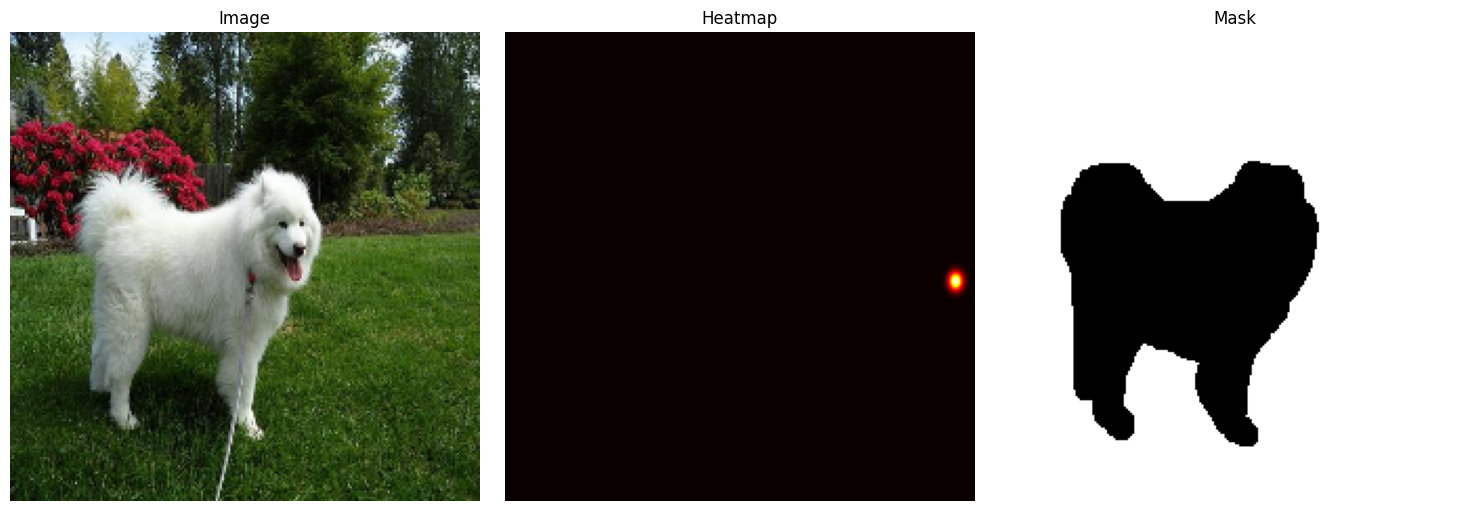

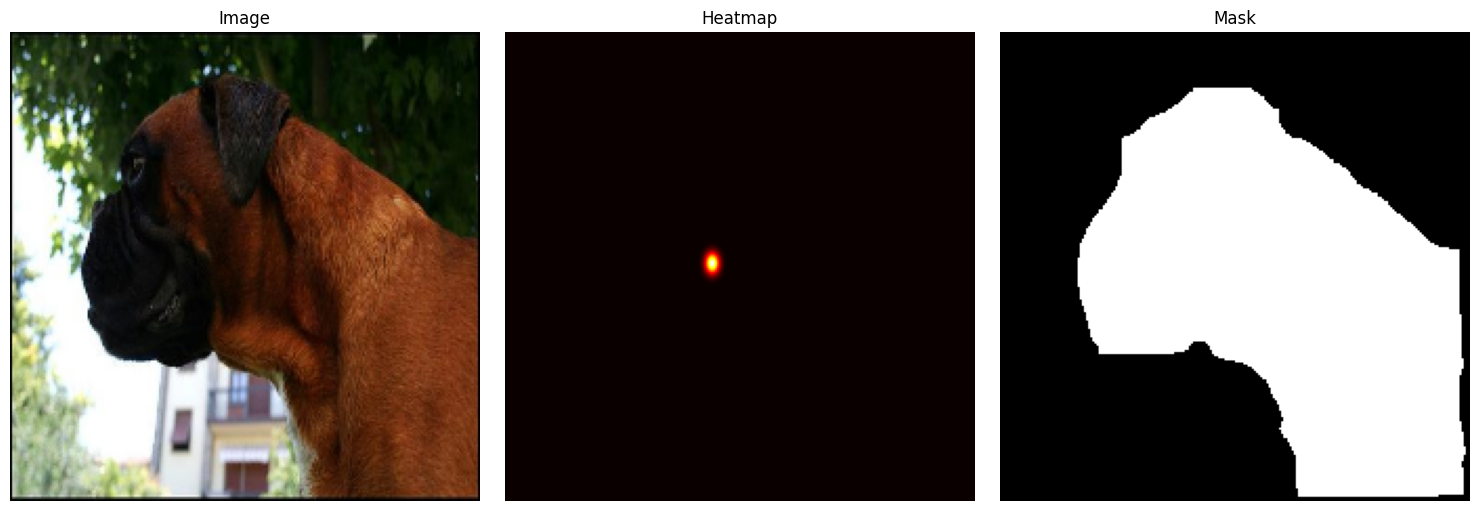

Image shape:  torch.Size([3, 224, 224])
Heatmap shape:  torch.Size([1, 224, 224])
Mask shape:  torch.Size([224, 224])


In [96]:
def plot_image(image, heatmap, mask):
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    # Plot the image
    axes[0].imshow(image.permute(1, 2, 0).numpy())
    axes[0].set_title("Image")
    axes[0].axis("off")

    # Plot the heatmap
    axes[1].imshow(heatmap.squeeze().numpy(), cmap='hot')
    axes[1].set_title("Heatmap")
    axes[1].axis("off")

    # Plot the mask
    axes[2].imshow(mask.squeeze().numpy(), cmap='gray')
    axes[2].set_title("Mask")
    axes[2].axis("off")

    plt.tight_layout()
    plt.show()
N=random.randint(0,BATCH_SIZE-1)

plot_image(images[N], heatmaps[N], masks[N])
N=random.randint(0,BATCH_SIZE-1)
plot_image(images[N], heatmaps[N], masks[N])
print("Image shape: ",images[N].shape)
print("Heatmap shape: ",heatmaps[N].shape)
print("Mask shape: ",masks[N].shape)

##### Implementation

In [80]:
# Implemented in
from models.prompt_based_unet import PromptUNet
# Based on the CLIPResnetSegmentationModel

##### Model Trainin

Best epoch:
    train_iou  train_loss   val_iou  val_loss
6   0.482596    0.637117  0.518401  0.622383


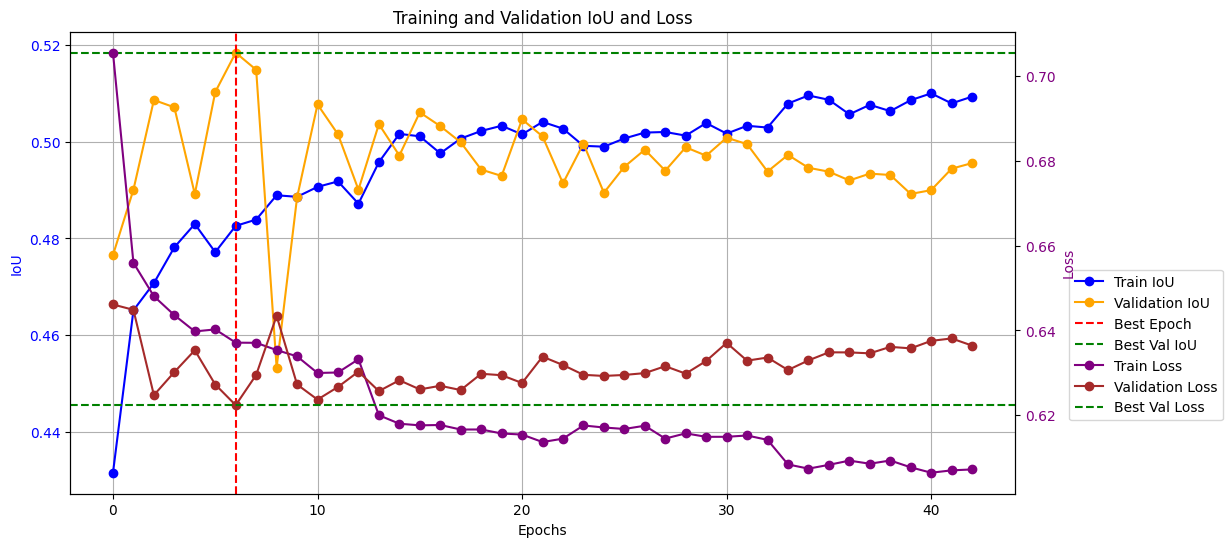

In [81]:
training_plot("UNet_PROMPT_experiment/result_outputs/summary.csv")

##### Model Test

In [110]:
from models.prompt_based_unet import PromptUNet

from Datasets.Prompt_based_segmentation.data_providers import test_dataset

prompt_unet = PromptUNet(device, n_classes=4).to(device)
checkpoint = torch.load("UNet_PROMPT_experiment/saved_models/train_model_13", map_location=device)
saved_state_dict = checkpoint["network"]
# assign weights to the model
new_state_dict = {k.replace("model.", "", 1): v for k, v in saved_state_dict.items()}
load_status = prompt_unet.load_state_dict(new_state_dict, strict=False)
print("Missing keys:", load_status.missing_keys)
print("Unexpected keys:", load_status.unexpected_keys)
torch.save(prompt_unet.state_dict(), "train_model_13_weights_only.pth")

C:\Users\jorge\AppData\Local\Temp\ipykernel_23972\1215216502.py:6: FutureWarning:

You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.



Missing keys: []
Unexpected keys: ['loss_criterion.weight']


In [109]:
load_status

_IncompatibleKeys(missing_keys=[], unexpected_keys=['loss_criterion.weight'])

In [ ]:


BATCH_SIZE = 1
test_dataloader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=True)





from models.unet_model import UNet

unet_raw = UNet(input_channels=3, n_filters=64, n_classes=4).to(device)
checkpoint = torch.load("models/weights/unet/unet_unet/train_model_36", map_location=device)
saved_state_dict = checkpoint["network"]
# assign weights to the model
new_state_dict = {k.replace("model.", "", 1): v for k, v in saved_state_dict.items()}
load_status = unet_raw.load_state_dict(new_state_dict, strict=False)
print("Missing keys:", load_status.missing_keys)
print("Unexpected keys:", load_status.unexpected_keys)


# 3 Evaluation and Comparison

### 3.a) quantitatively and Qualitatively

##### Selected images for qualitative comparison

Images chosen to make qualtitative comparison:


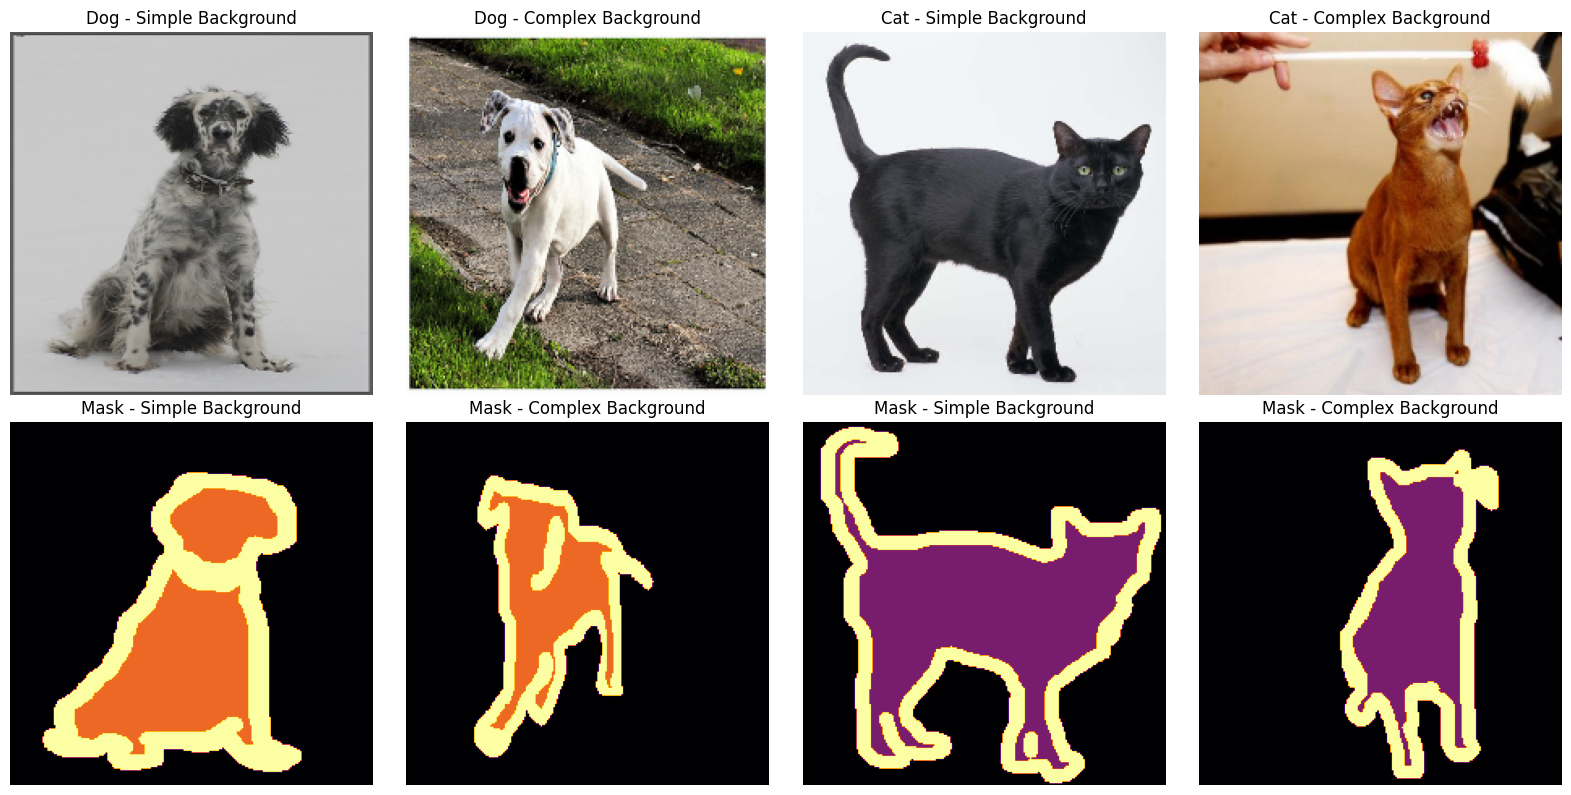

In [99]:
from Datasets.Segmentation.data_providers import test_dataset
from utils import evaluate_model, get_test_sample, evaluate_model_on_sample

test_dataloader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=True)

# A Dog with simple background
image_path = "Datasets/Segmentation/Test/color/english_setter_96.jpg"
mask_path = "Datasets/Segmentation/Test/label/english_setter_96.png"
image_dog_easy_back, mask_dog_easy_back = get_test_sample(image_path, mask_path)
# A Dog with complex background
image_path = "Datasets/Segmentation/Test/color/american_bulldog_89.jpg"
mask_path = "Datasets/Segmentation/Test/label/american_bulldog_89.png"
image_dog_hard_back, mask_dog_hard_back = get_test_sample(image_path, mask_path)
# A Cat with simple background
image_path = "Datasets/Segmentation/Test/color/Bombay_24.jpg"
mask_path = "Datasets/Segmentation/Test/label/Bombay_24.png"
image_cat_easy_back, mask_cat_easy_back = get_test_sample(image_path, mask_path)
# # A Cat with complex background
image_path = "Datasets/Segmentation/Test/color/Abyssinian_20.jpg"
mask_path = "Datasets/Segmentation/Test/label/Abyssinian_20.png"
image_cat_hard_back, mask_cat_hard_back = get_test_sample(image_path, mask_path)

print("Images chosen to make qualtitative comparison:")

fig, axes = plt.subplots(2, 4, figsize=(16, 8))  # Adjusted figsize for better visualization

# Plot Dog with simple background
axes[0, 0].imshow(image_dog_easy_back.permute(1, 2, 0).numpy())
axes[0, 0].set_title("Dog - Simple Background")
axes[0, 0].axis("off")
axes[1, 0].imshow(mask_dog_easy_back.numpy(), cmap='inferno')
axes[1, 0].set_title("Mask - Simple Background")
axes[1, 0].axis("off")

# Plot Dog with complex background
axes[0, 1].imshow(image_dog_hard_back.permute(1, 2, 0).numpy())
axes[0, 1].set_title("Dog - Complex Background")
axes[0, 1].axis("off")
axes[1, 1].imshow(mask_dog_hard_back.numpy(), cmap='inferno')
axes[1, 1].set_title("Mask - Complex Background")
axes[1, 1].axis("off")

# Plot Cat with simple background
axes[0, 2].imshow(image_cat_easy_back.permute(1, 2, 0).numpy())
axes[0, 2].set_title("Cat - Simple Background")
axes[0, 2].axis("off")
axes[1, 2].imshow(mask_cat_easy_back.numpy(), cmap='inferno')
axes[1, 2].set_title("Mask - Simple Background")
axes[1, 2].axis("off")

# Plot Cat with complex background
axes[0, 3].imshow(image_cat_hard_back.permute(1, 2, 0).numpy())
axes[0, 3].set_title("Cat - Complex Background")
axes[0, 3].axis("off")
axes[1, 3].imshow(mask_cat_hard_back.numpy(), cmap='inferno')
axes[1, 3].set_title("Mask - Complex Background")
axes[1, 3].axis("off")

plt.tight_layout()
plt.show()

##### Quantitative comparison

UNet Alone

In [84]:
from models.unet_model import UNet

unet_raw = UNet(input_channels=3, n_filters=64, n_classes=4).to(device)
checkpoint = torch.load("models/weights/unet/unet_unet/train_model_36", map_location=device)
saved_state_dict = checkpoint["network"]
# assign weights to the model
new_state_dict = {k.replace("model.", "", 1): v for k, v in saved_state_dict.items()}
load_status = unet_raw.load_state_dict(new_state_dict, strict=False)
print("Missing keys:", load_status.missing_keys)
print("Unexpected keys:", load_status.unexpected_keys)

C:\Users\jorge\AppData\Local\Temp\ipykernel_23972\1329902227.py:4: FutureWarning:

You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.



Missing keys: []
Unexpected keys: ['loss_criterion.weight']


In [4]:
evaluate_model(unet_raw, test_dataloader, device=device,ignore_border=True, limit_samples=False) # Set limit_samples=True to compile fast only 10 samples

100%|██████████| 926/926 [21:45<00:00,  1.41s/it]

Background - IoU: 0.7168 ± 0.0877, Dice: 0.8319
Cat - IoU: 0.2015 ± 0.1537, Dice: 0.3079
Dog - IoU: 0.3853 ± 0.1331, Dice: 0.5420
Border - IoU: nan ± nan, Dice: 0.5722
TOTAL Mean IoU: 0.4345 ± 0.2486
TOTAL Mean Dice: 0.5635
TOTAL Pixel Accuracy: 0.6787



c:\Users\jorge\OneDrive - unimilitar.edu.co\AI and Machine Learning\Computer_Vision\coursework\U-Net-Segmentation\utils.py:186: RuntimeWarning: Mean of empty slice
  mean_iou_per_class = np.nanmean(iou_array, axis=0)
c:\Users\jorge\anaconda3\envs\cv_segmentation\lib\site-packages\numpy\lib\nanfunctions.py:1879: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


UNet pretrained Autoencoder

In [85]:
from models.unet_model import UNet

unet_autoencoder = UNet(input_channels=3, n_filters=64, n_classes=4).to(device)
checkpoint = torch.load("models/weights/autoencoder/autoencoder_unet/unet_best_0.9319.pth", map_location=device)
# Inspect the keys in the checkpoint to find the correct key
print("Available keys in checkpoint:", checkpoint.keys())
saved_state_dict = checkpoint  # Assuming the checkpoint itself is the state dictionary
new_state_dict = {k.replace("model.", "", 1): v for k, v in saved_state_dict.items()}
load_status = unet_autoencoder.load_state_dict(new_state_dict, strict=False)
print("Missing keys:", load_status.missing_keys)
print("Unexpected keys:", load_status.unexpected_keys)

C:\Users\jorge\AppData\Local\Temp\ipykernel_23972\2927452805.py:4: FutureWarning:

You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.



Available keys in checkpoint: odict_keys(['cblock1.conv1.weight', 'cblock1.conv1.bias', 'cblock1.conv2.weight', 'cblock1.conv2.bias', 'cblock2.conv1.weight', 'cblock2.conv1.bias', 'cblock2.conv2.weight', 'cblock2.conv2.bias', 'cblock3.conv1.weight', 'cblock3.conv1.bias', 'cblock3.conv2.weight', 'cblock3.conv2.bias', 'cblock4.conv1.weight', 'cblock4.conv1.bias', 'cblock4.conv2.weight', 'cblock4.conv2.bias', 'cblock5.conv1.weight', 'cblock5.conv1.bias', 'cblock5.conv2.weight', 'cblock5.conv2.bias', 'ublock6.upconv.weight', 'ublock6.upconv.bias', 'ublock6.conv1.weight', 'ublock6.conv1.bias', 'ublock6.conv2.weight', 'ublock6.conv2.bias', 'ublock7.upconv.weight', 'ublock7.upconv.bias', 'ublock7.conv1.weight', 'ublock7.conv1.bias', 'ublock7.conv2.weight', 'ublock7.conv2.bias', 'ublock8.upconv.weight', 'ublock8.upconv.bias', 'ublock8.conv1.weight', 'ublock8.conv1.bias', 'ublock8.conv2.weight', 'ublock8.conv2.bias', 'ublock9.upconv.weight', 'ublock9.upconv.bias', 'ublock9.conv1.weight', 'ubloc

In [6]:
evaluate_model(unet_autoencoder, test_dataloader, device=device,ignore_border=True, limit_samples=False) # Set limit_samples=True to compile fast only 10 samples

100%|██████████| 926/926 [20:20<00:00,  1.32s/it]

Background - IoU: 0.6247 ± 0.0921, Dice: 0.7649
Cat - IoU: 0.0120 ± 0.0167, Dice: 0.0232
Dog - IoU: 0.3167 ± 0.1217, Dice: 0.4673
Border - IoU: nan ± nan, Dice: 0.3220
TOTAL Mean IoU: 0.3178 ± 0.2653
TOTAL Mean Dice: 0.3944
TOTAL Pixel Accuracy: 0.6099


UNet with CLIP's encoder

In [102]:
from models.clip_based_unet import CLIPResnetSegmentationModel

unet_clip = CLIPResnetSegmentationModel(device, n_classes=4).to(device)
checkpoint = torch.load("CLIP_x2weight_experiment/saved_models/train_model_22", map_location=device)

saved_state_dict = checkpoint["network"]
model_dict = unet_clip.state_dict()
decoder_weights = {k.replace("model.", "", 1): v for k, v in saved_state_dict.items() if "decoder" in k}
model_dict.update(decoder_weights)
load_status = unet_clip.load_state_dict(model_dict)
print("Missing keys:", load_status.missing_keys)
print("Unexpected keys:", load_status.unexpected_keys)


C:\Users\jorge\AppData\Local\Temp\ipykernel_23972\435155959.py:4: FutureWarning:

You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.



Missing keys: []
Unexpected keys: []


In [104]:
evaluate_model(unet_clip, test_dataloader, device=device,ignore_border=False, limit_samples=True) # Set limit_samples=True to compile fast only 10 samples

  7%|▋         | 11/155 [01:32<20:04,  8.36s/it]

Background - IoU: 0.4932 ± 0.0253, Dice: 0.6602
Cat - IoU: 0.4785 ± 0.0416, Dice: 0.6461
Dog - IoU: 0.6725 ± 0.0436, Dice: 0.8033
Border - IoU: 0.2845 ± 0.0241, Dice: 0.4425
TOTAL Mean IoU: 0.4822 ± 0.1416
TOTAL Mean Dice: 0.6380
TOTAL Pixel Accuracy: 0.6449


#### Results

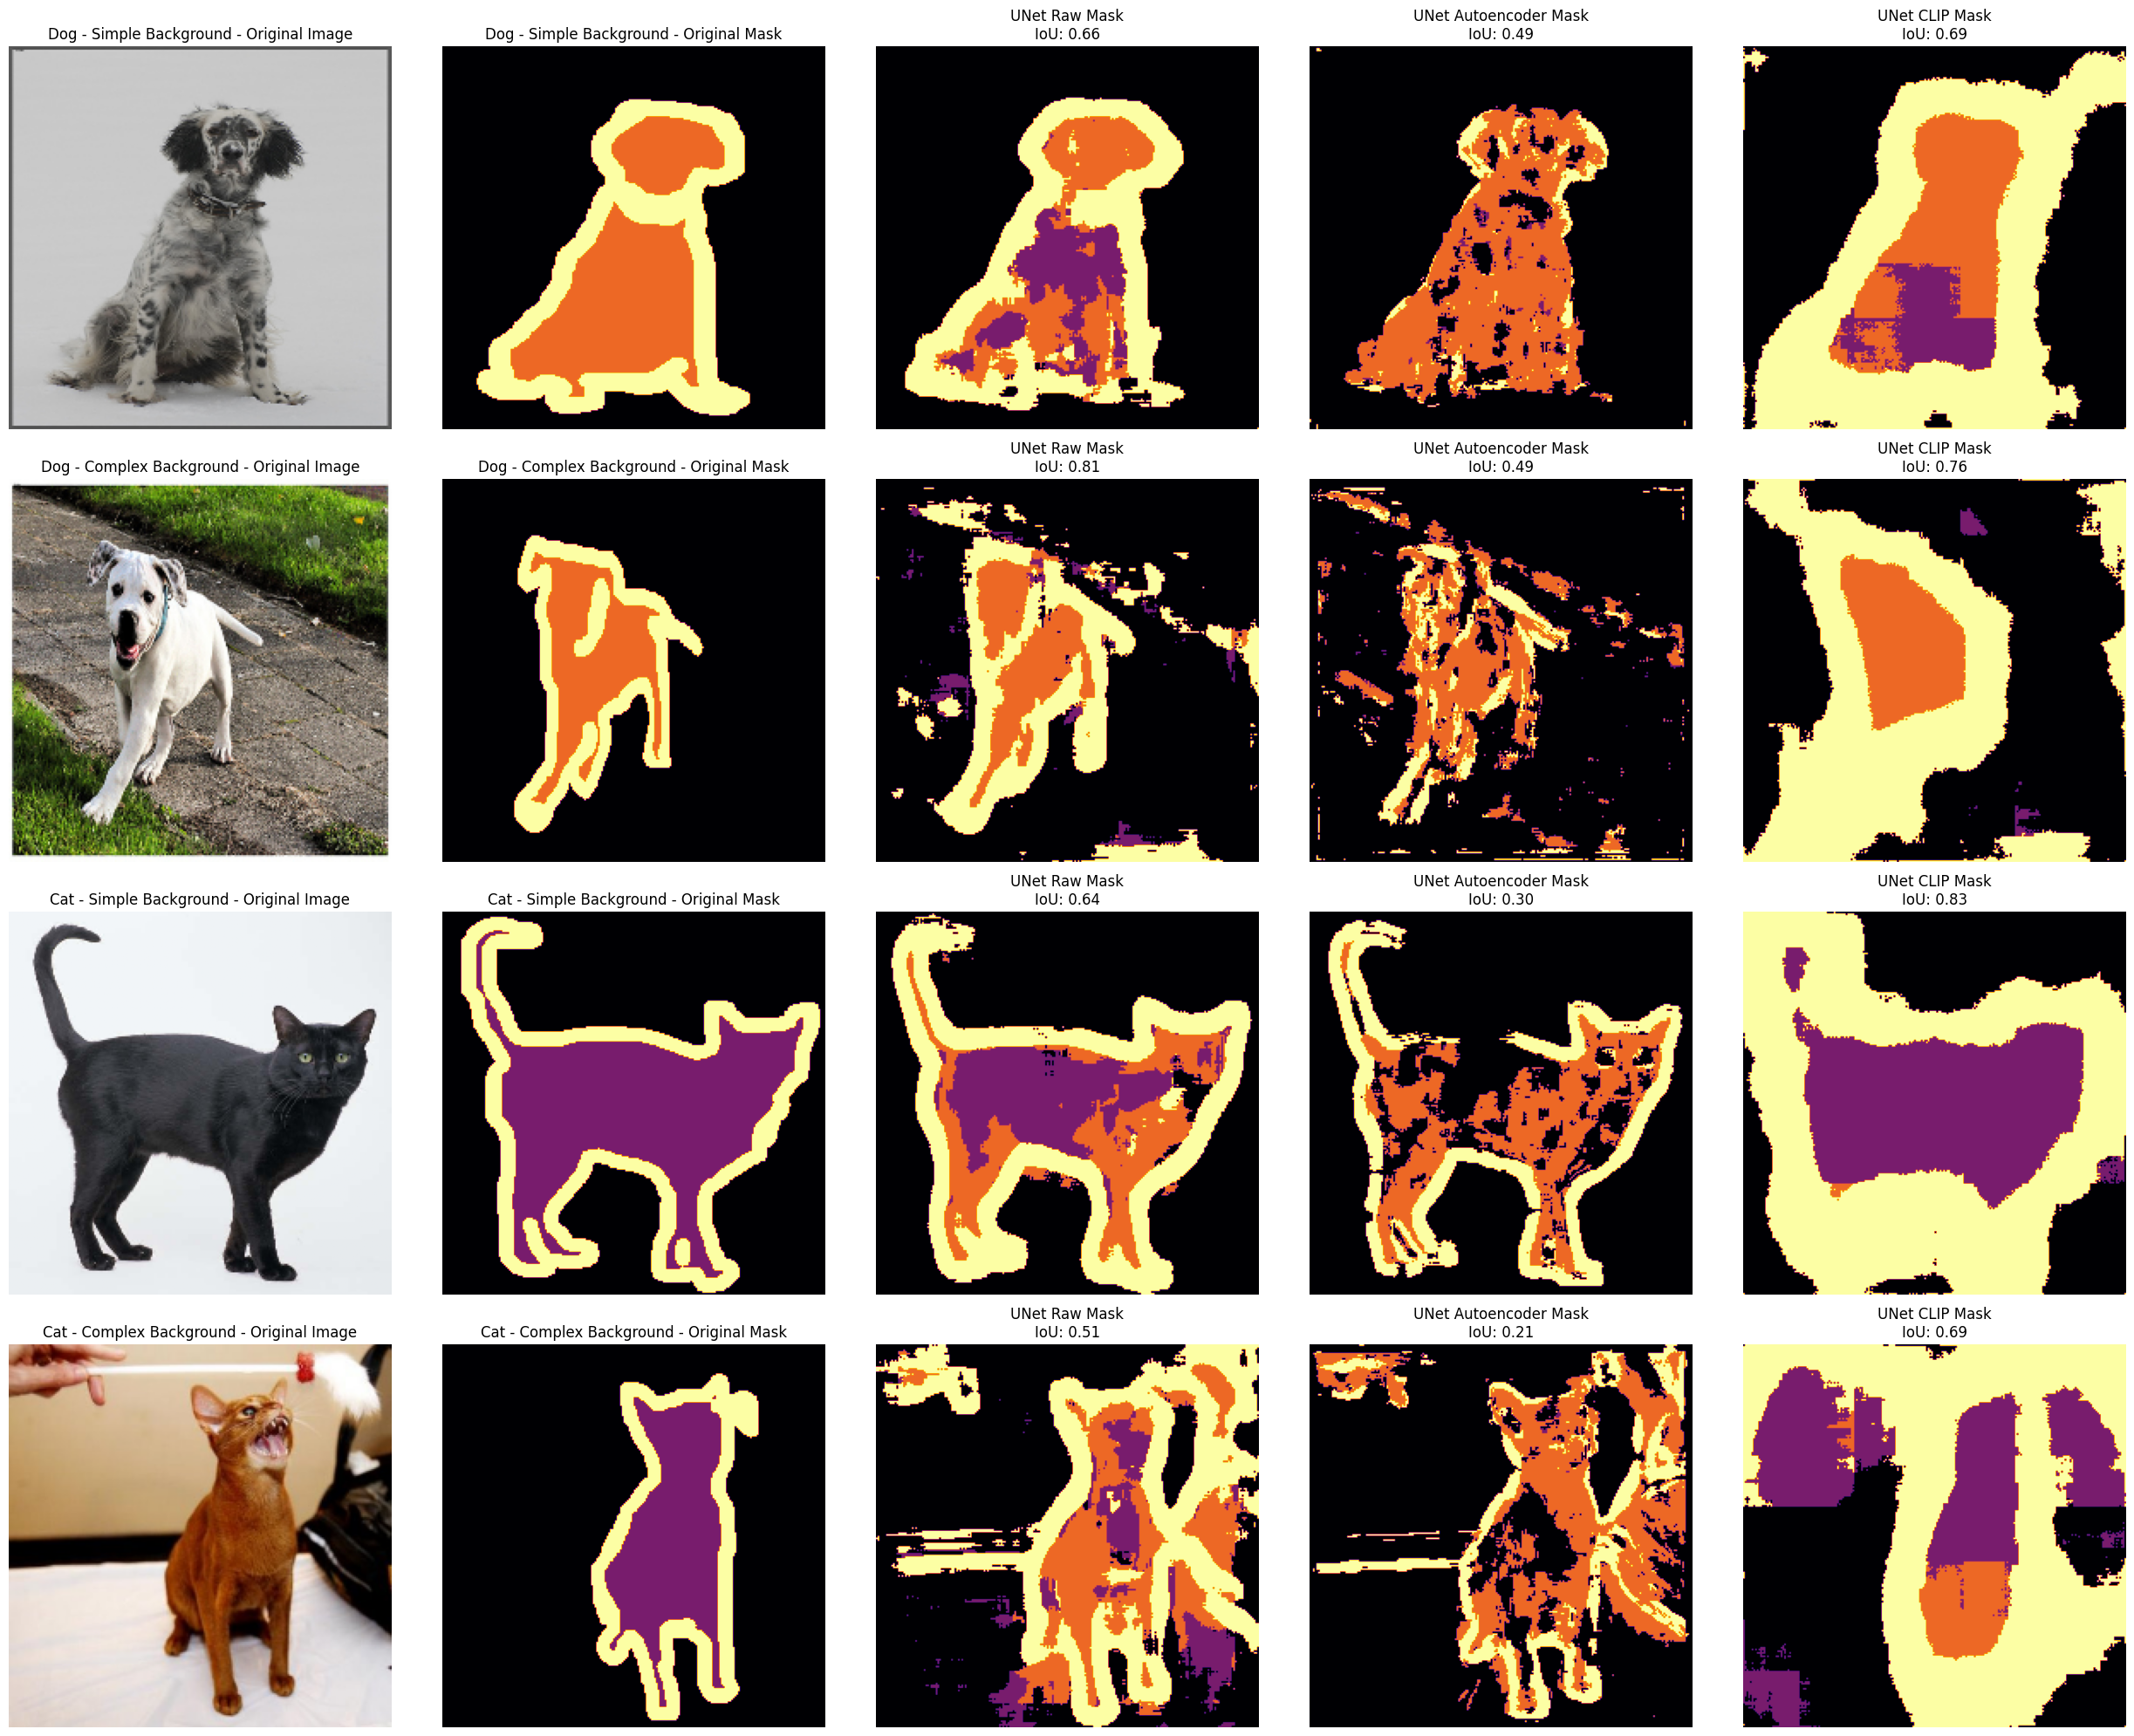

In [87]:
# On Dog with simple background
unet_raw_mask = evaluate_model_on_sample(unet_raw, image_dog_easy_back, mask_dog_easy_back)
unet_autoencoder_mask = evaluate_model_on_sample(unet_autoencoder, image_dog_easy_back, mask_dog_easy_back)
unet_clip_mask = evaluate_model_on_sample(unet_clip, image_dog_easy_back, mask_dog_easy_back)
# On Dog with complex background
unet_raw_mask_hard = evaluate_model_on_sample(unet_raw, image_dog_hard_back, mask_dog_hard_back)
unet_autoencoder_mask_hard = evaluate_model_on_sample(unet_autoencoder, image_dog_hard_back, mask_dog_hard_back)
unet_clip_mask_hard = evaluate_model_on_sample(unet_clip, image_dog_hard_back, mask_dog_hard_back)
# On Cat with simple background
unet_raw_mask_cat = evaluate_model_on_sample(unet_raw, image_cat_easy_back, mask_cat_easy_back)
unet_autoencoder_mask_cat = evaluate_model_on_sample(unet_autoencoder, image_cat_easy_back, mask_cat_easy_back)
unet_clip_mask_cat = evaluate_model_on_sample(unet_clip, image_cat_easy_back, mask_cat_easy_back)
# On Cat with complex background
unet_raw_mask_cat_hard = evaluate_model_on_sample(unet_raw, image_cat_hard_back, mask_cat_hard_back)
unet_autoencoder_mask_cat_hard = evaluate_model_on_sample(unet_autoencoder, image_cat_hard_back, mask_cat_hard_back)
unet_clip_mask_cat_hard = evaluate_model_on_sample(unet_clip, image_cat_hard_back, mask_cat_hard_back)

# Cat Class: 1, Dog Class: 2, Background Class: 0

fig, axes = plt.subplots(4, 5, figsize=(25, 20))

# Titles for each row
titles = ["Dog - Simple Background", "Dog - Complex Background", "Cat - Simple Background", "Cat - Complex Background"]

# Masks and IoU calculations
masks = [
    (image_dog_easy_back, mask_dog_easy_back, unet_raw_mask, unet_autoencoder_mask, unet_clip_mask),
    (image_dog_hard_back, mask_dog_hard_back, unet_raw_mask_hard, unet_autoencoder_mask_hard, unet_clip_mask_hard),
    (image_cat_easy_back, mask_cat_easy_back, unet_raw_mask_cat, unet_autoencoder_mask_cat, unet_clip_mask_cat),
    (image_cat_hard_back, mask_cat_hard_back, unet_raw_mask_cat_hard, unet_autoencoder_mask_cat_hard, unet_clip_mask_cat_hard),
]

# Iterate over rows
for i, (original_image, original_mask, raw_mask, autoencoder_mask, clip_mask) in enumerate(masks):
    # Original image
    axes[i, 0].imshow(original_image.permute(1, 2, 0).numpy())
    axes[i, 0].set_title(f"{titles[i]} - Original Image")
    axes[i, 0].axis("off")

    # Original mask
    axes[i, 1].imshow(original_mask.numpy(), cmap='inferno')
    axes[i, 1].set_title(f"{titles[i]} - Original Mask")
    axes[i, 1].axis("off")

    # UNet Raw mask
    iou_raw = np.sum((raw_mask == original_mask.numpy()) & (original_mask.numpy() > 0)) / np.sum(original_mask.numpy() > 0)
    axes[i, 2].imshow(raw_mask, cmap='inferno')
    axes[i, 2].set_title(f"UNet Raw Mask\nIoU: {iou_raw:.2f}")
    axes[i, 2].axis("off")

    # UNet Autoencoder mask
    iou_autoencoder = np.sum((autoencoder_mask == original_mask.numpy()) & (original_mask.numpy() > 0)) / np.sum(original_mask.numpy() > 0)
    axes[i, 3].imshow(autoencoder_mask, cmap='inferno')
    axes[i, 3].set_title(f"UNet Autoencoder Mask\nIoU: {iou_autoencoder:.2f}")
    axes[i, 3].axis("off")

    # UNet CLIP mask
    iou_clip = np.sum((clip_mask == original_mask.numpy()) & (original_mask.numpy() > 0)) / np.sum(original_mask.numpy() > 0)
    axes[i, 4].imshow(clip_mask, cmap='inferno')
    axes[i, 4].set_title(f"UNet CLIP Mask\nIoU: {iou_clip:.2f}")
    axes[i, 4].axis("off")

plt.tight_layout()
plt.show()


### 3.b) Performance Comparison

IoU
+-------------------+------------------------+------------------------+------------------------+
| Class             | UNet w/ CLIP's AE      | UNet Itself            | UNet w/ AE Encoder     |
+-------------------+------------------------+------------------------+------------------------+
| Background        | 0.4932 ± 0.0253        | 0.7168 ± 0.0877        | 0.6247 ± 0.0921        |
| Cat               | 0.4785 ± 0.0416        | 0.2015 ± 0.1537        | 0.0120 ± 0.0167        |
| Dog               | 0.6725 ± 0.0436        | 0.3853 ± 0.1331        | 0.3167 ± 0.1217        |
| Border            | 0.2845 ± 0.0241        | nan ± nan              | nan ± nan              |
| **Mean IoU**      | 0.4822 ± 0.1416        | 0.4345 ± 0.2486        | 0.3178 ± 0.2653        |

Dice
+-------------------+----------------+----------------+----------------+
| Class             | UNet w/ CLIP's AE | UNet Itself | UNet w/ AE Encoder |
+-------------------+----------------+----------------+----------------+
| Background        | 0.6602         | 0.8319         | 0.7649         |
| Cat               | 0.6461         | 0.3079         | 0.0232         |
| Dog               | 0.8033         | 0.5420         | 0.4673         |
| Border            | 0.4425         | 0.5722         | 0.3220         |
| **Mean Dice**     | 0.6380         | 0.5635         | 0.3944         |
Pixel Accuracy
+-------------------------+----------------+
| Model                   | Pixel Accuracy |
+-------------------------+----------------+
| UNet w/ CLIP's AE       | 0.6449         |
| UNet Itself             | 0.6787         |
| UNet w/ AE Encoder      | 0.6099         |



Each metrics typical use:

- IoU: Strict measure of overlap (use in general segmentation tasks)
- Dice: More Apt for class imbalance (use in small regions where false negatives are critical)
- Pixel Accuracy: Simple performance overview (use when per-pixel correctness matters)

Analysis per metric:

- IoU:
    Best: 
        UNet with CLIP's encoder 
            Mean: 0.6066
- Dice:
    Best:
        UNet with CLIP's encoder 
            Mean: 0.6380
                But surpassed by UNet itself for class Border and Background
- Pixel Accuracy:
    Best:
        UNet Alone
            Mean: 0.679



Overall, there is a tendency across all models to classify pixels as either dog or background, even when those pixels belong to other classes. Objects in the background are the main source of misclassification of pixels belonging to "Background" as "Cat", "Dog", or "Border". Though the loss function was weighted in favor of the underrepresented categories (cats and borders), it still fails to account for the strong imbalance present in the data. The differences between the model's performance is detailed below:



UNet with CLIP's encoder weights is the model with the strongest class identification and the most semantic understanding. It is by far the one that identified cats best — and the same goes for dogs. It struggled a bit more than the others when predicting background, but still performed well enough. From the graph, it's clear that the predictions made by this model are solid, cohesive regions centered around where the animal is located. In images with simple backgrounds, the predictions are almost perfect, but in noisy backgrounds where other objects are present, this model tends to misclassify some of those objects as either a cat or a dog. The predictions from this model tend to lose the detailed shape of the animal. However, it is the only model that produced absolutely no holes of the class "background" within the identified animal — which shows that, once it has decided on an animal, it treats it as a whole. Regarding the encoder, CLIP-based features are pretrained to associate image content with high-level categories, but they may overgeneralize when local features (like fur or paws) aren't distinctive enough. Also, this model predicts the "border" class much more frequently than the others. This could be because CLIP generalizes the idea of "boundary-ness" from its broad language-image training, but possibly confuses object edges with the specific "border" class — which might explain why this is the only model that draws overly thick borders around the animals.


Vanilla UNet shows strong localization of the class pixels — it knows where the pixels should be and has a strong grasp of low-level features — but still misclassifies large portions of the animals, both in clean and noisy backgrounds. It almost always identifies the general shape of the animal correctly, but just like the CLIP-based model, it misclassifies other objects in the image as either cats or dogs. It is the best model when it comes to predicting the background, but its suspiciously high score suggests this might come at the cost of misclassifying pixels that actually belong to a cat or a dog. Its understanding of the cat class is weak, as shown by the very low scores in both IoU and Dice. It achieved the highest pixel accuracy, but this could be simply due to the high frequency of background predictions — the most represented class — which it is biased toward. The predicted masks often contain "holes" where pixels inside an animal are wrongly predicted as background, showing the model lacks a solid semantic understanding of the animals. Lastly, when complex backgrounds are present, they are often misclassified as "borders" rather than other animal classes. This might be because the model learned to detect edges between objects — so instead of identifying the animal itself, it ends up detecting edges between other elements and the background, and confusing these with the border class.

The UNet with encoder weights pretrained using an autoencoder is the worst of all. It almost never identifies cats and is clearly biased towards predicting "dog" and "background." It sometimes picks up the general shape of the animal, but the predictions are incomplete — borders often fade or vanish entirely. It also tends to misclassify background pixels as "dog" and vice versa. Many of the predicted animals have large sections inside them labeled as background. It also has a recurring issue where edges in the image are misclassified as either dog or border. This model was expected to perform better than the vanilla UNet, but looking at the figure that compares the original vs. predicted images (after passing them through the autoencoder used for pretraining), it's clear that the reconstructions were very blurry. That suggests the autoencoder didn't learn rich enough features. The blurriness means small details like fur and whiskers were lost — and since the encoder's weights were frozen during segmentation training, the model never learned to recognize those details. The autoencoder likely learned smoothed averages of visual patterns, losing important sharpness (edges, textures) that are crucial for segmentation. This model would likely perform better if pretrained with a better autoencoder that is capable of preserving fine details.

Conclusions

The predictions on these models can be further polished using conditional random fields, proven useful in segmentation tasks in works as \cite{kumar2003discriminative} where they incorpore neighborhood spatial dependencies in the labels, and \cite{he2004multiscale} where they incorporated contextual features for labeling images.

the performance of a segmentation model with pretraines and freezed encoder weights is heavily dependent on the context where the pretraining happened. The comparisons in the graph showed a clrear example of this. The UNet with poor encoder weights from the autoencoder made it loose important fine details to differentiate between cats and dogs, and the encoder from the CLIP model made the UNet segmentation learn broad phase segmentation of the objects in the image very well.


@article{kumar2003discriminative,
  title={Discriminative fields for modeling spatial dependencies in natural images},
  author={Kumar, Sanjiv and Hebert, Martial},
  journal={Advances in neural information processing systems},
  volume={16},
  year={2003}
}

@inproceedings{he2004multiscale,
  title={Multiscale conditional random fields for image labeling},
  author={He, Xuming and Zemel, Richard S and Carreira-Perpin{\'a}n, Miguel A},
  booktitle={Proceedings of the 2004 IEEE Computer Society Conference on Computer Vision and Pattern Recognition, 2004. CVPR 2004.},
  volume={2},
  pages={II--II},
  year={2004},
  organization={IEEE}
}